In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [2]:

plt.style.use('dark_background')

def split_and_merge(image, threshold):
    def split(img, x, y, w, h):
        roi = img[y:y+h, x:x+w]
        mean, std_dev = cv2.meanStdDev(roi)
        if std_dev[0][0] > threshold and w > 4 and h > 4:
            mw, mh = w // 2, h // 2
            split(img, x, y, mw, mh)
            split(img, x + mw, y, w - mw, mh)
            split(img, x, y + mh, mw, h - mh)
            split(img, x + mw, y + mh, w - mw, h - mh)
        else:
            cv2.rectangle(segmented_img, (x, y), (x + w, y + h), int(mean[0][0]), -1)
            cv2.rectangle(segmented_img, (x, y), (x + w, y + h), 0, 1) # grid lines

    segmented_img = np.zeros_like(image)
    h, w = image.shape
    split(image, 0, 0, w, h)
    return segmented_img



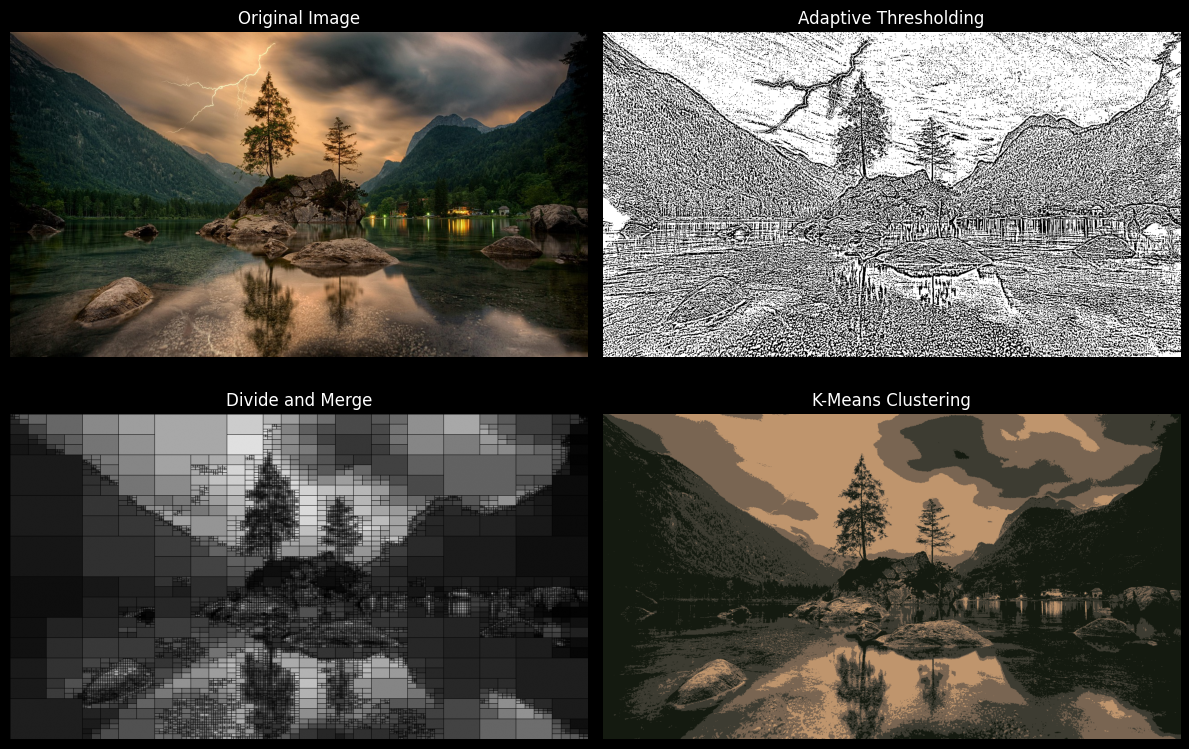

Yash Agarwal
23BAI0011


In [4]:
image_path = 'sample.jpg' 
img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Adaptive Thresholding
adaptive_thresh = cv2.adaptiveThreshold(
    gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
)

# 3. Divide and Merge Method
div_merge_result = split_and_merge(gray.copy(), threshold=15)

# 4. K-Means Clustering
pixel_values = img.reshape((-1, 3)).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
k = 4 # Number of clusters
_, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers)
kmeans_result = centers[labels.flatten()]
kmeans_result = kmeans_result.reshape(img.shape)

# Plotting Results
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title('Original Image')
plt.axis('off')
plt.subplot(2, 2, 2), plt.imshow(adaptive_thresh, cmap='gray'), plt.title('Adaptive Thresholding')
plt.axis('off')
plt.subplot(2, 2, 3), plt.imshow(div_merge_result, cmap='gray'), plt.title('Divide and Merge')
plt.axis('off')
plt.subplot(2, 2, 4), plt.imshow(cv2.cvtColor(kmeans_result, cv2.COLOR_BGR2RGB)), plt.title('K-Means Clustering')
plt.axis('off')
plt.tight_layout()
plt.show()
print("Yash Agarwal\n23BAI0011")

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pywt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import mean_squared_error as mse



In [10]:
plt.style.use('dark_background')

def calculate_metrics(original, reconstructed, transform_name):
    """Calculates and prints MSE, PSNR, and SSIM."""
    m_mse = mse(original, reconstructed)
    m_psnr = psnr(original, reconstructed, data_range=255)
    m_ssim = ssim(original, reconstructed, data_range=255)
    
    print(f"--- Metrics for {transform_name} ---")
    print(f"MSE:  {m_mse:.4f}")
    print(f"PSNR: {m_psnr:.4f} dB")
    print(f"SSIM: {m_ssim:.4f}\n")


--- Metrics for DFT ---
MSE:  0.5096
PSNR: 51.0589 dB
SSIM: 0.9998

--- Metrics for DCT ---
MSE:  0.2586
PSNR: 54.0039 dB
SSIM: 0.9992

--- Metrics for Haar Wavelet ---
MSE:  0.0103
PSNR: 68.0155 dB
SSIM: 1.0000

Yash Agarwal
23BAI0011


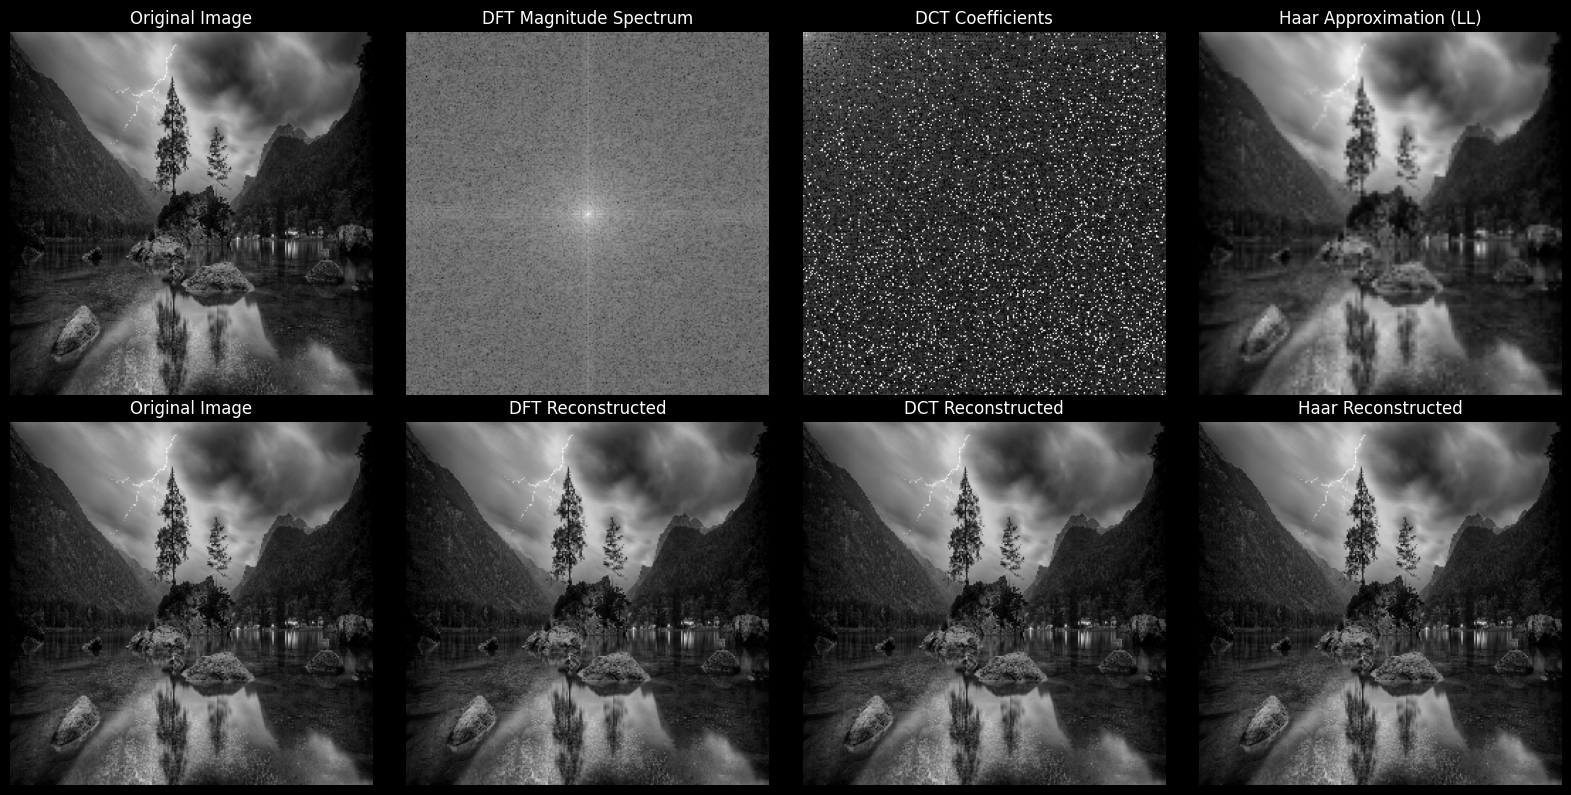

In [ ]:

image_path = 'sample.jpg' 
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Image not found. Please check the file path.")
else:
    img = cv2.resize(img, (256, 256))

    dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]) + 1e-5)

    f_ishift = np.fft.ifftshift(dft_shift)
    img_back_dft = cv2.idft(f_ishift)
    img_back_dft = cv2.magnitude(img_back_dft[:, :, 0], img_back_dft[:, :, 1])
    img_back_dft = cv2.normalize(img_back_dft, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    img_float = np.float32(img) / 255.0
    dct = cv2.dct(img_float)
    dct_visual = np.uint8(np.log(abs(dct) * 255 + 1e-5) * 20) 

    img_back_dct = cv2.idct(dct)
    img_back_dct = np.clip(img_back_dct * 255, 0, 255).astype(np.uint8)

    coeffs2 = pywt.dwt2(img, 'haar')
    LL, (LH, HL, HH) = coeffs2
    LL_vis = np.uint8(LL / np.max(LL) * 255) 

    img_back_haar = pywt.idwt2(coeffs2, 'haar')
    img_back_haar = np.clip(img_back_haar, 0, 255).astype(np.uint8)

    calculate_metrics(img, img_back_dft, "DFT")
    calculate_metrics(img, img_back_dct, "DCT")
    calculate_metrics(img, img_back_haar, "Haar Wavelet")
    print("Yash Agarwal\n23BAI0011")

    plt.figure(figsize=(16, 8))

    plt.subplot(2, 4, 1), plt.imshow(img, cmap='gray'), plt.title('Original Image')
    plt.axis('off')
    plt.subplot(2, 4, 2), plt.imshow(magnitude_spectrum, cmap='gray'), plt.title('DFT Magnitude Spectrum')
    plt.axis('off')
    plt.subplot(2, 4, 3), plt.imshow(dct_visual, cmap='gray'), plt.title('DCT Coefficients')
    plt.axis('off')
    plt.subplot(2, 4, 4), plt.imshow(LL_vis, cmap='gray'), plt.title('Haar Approximation (LL)')
    plt.axis('off')

    plt.subplot(2, 4, 5), plt.imshow(img, cmap='gray'), plt.title('Original Image')
    plt.axis('off')
    plt.subplot(2, 4, 6), plt.imshow(img_back_dft, cmap='gray'), plt.title('DFT Reconstructed')
    plt.axis('off')
    plt.subplot(2, 4, 7), plt.imshow(img_back_dct, cmap='gray'), plt.title('DCT Reconstructed')
    plt.axis('off')
    plt.subplot(2, 4, 8), plt.imshow(img_back_haar, cmap='gray'), plt.title('Haar Reconstructed')
    plt.axis('off')

    plt.tight_layout()
    plt.show()